In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

# Загрузим данные и удалим дубликаты из датасета

In [3]:
df = pd.read_csv('../data/raw/heart.csv')
print('Размер исходного датасета:', df.shape)
print('Количество полных дубликатов:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Размер после удаления дубликатов:', df.shape)

Размер исходного датасета: (1025, 14)
Количество полных дубликатов: 723
Размер после удаления дубликатов: (302, 14)


# Основная информация о данных 

In [4]:
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print(f"\nТипы данных:")
print(df.dtypes.value_counts())

Размер данных: 302 строк, 14 столбцов

Типы данных:
int64      13
float64     1
Name: count, dtype: int64


In [5]:
target_col = 'target'

continuous_cols = [
    'age',
    'trestbps',
    'chol',
    'thalach',
    'oldpeak'
]

binary_cols = [
    'sex',
    'fbs',
    'exang'
]

categorical_cols = [
    'cp',
    'restecg',
    'slope',
    'ca',
    'thal'
]

print('Непрерывные признаки:', continuous_cols)
print('Бинарные признаки:', binary_cols)
print('Категориальные признаки:', categorical_cols)

Непрерывные признаки: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Бинарные признаки: ['sex', 'fbs', 'exang']
Категориальные признаки: ['cp', 'restecg', 'slope', 'ca', 'thal']


# Первичный анализ(EDA)

In [6]:
print("\nПервые 5 строк ")
print(df.head())

print("\nПоследние 5 строк ")
print(df.tail())


Первые 5 строк 
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  

Последние 5 строк 
     age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  \
297   68    0   2       120   211    0        0      115      0      1.5   
298   44    0   2       108   141    0        1      175      0      0.6   
299   52    1   0       128   255    0        1      161      1      0.0   
300   59    1   3       160   273    0  

In [7]:
print("\n Статистика непрерывных признаков ")
display(df[continuous_cols].describe())


 Статистика непрерывных признаков 


,age,trestbps,chol,thalach,oldpeak
count,302.00000,302.000000,302.000000,302.000000,302.000000
mean,54.42053,131.602649,246.500000,149.569536,1.043046
std,9.04797,17.563394,51.753489,22.903527,1.161452
min,29.00000,94.000000,126.000000,71.000000,0.000000
25%,48.00000,120.000000,211.000000,133.250000,0.000000
50%,55.50000,130.000000,240.500000,152.500000,0.800000
75%,61.00000,140.000000,274.750000,166.000000,1.600000
max,77.00000,200.000000,564.000000,202.000000,6.200000


In [8]:
print("\nАнализ пропусков")
df.isna().sum()
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    'Кол-во пропусков': missing,
    '% пропусков': missing_pct
}).sort_values('% пропусков', ascending=False)
print(missing_table[missing_table['Кол-во пропусков'] > 0])


Анализ пропусков
Empty DataFrame
Columns: [Кол-во пропусков, % пропусков]
Index: []


Заметим, что нет пропусков, значит хороший датасет

# Полная информация о данных 

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


In [10]:
for col in binary_cols + categorical_cols:
    print(f"\nПризнак: {col}")
    print(df[col].value_counts().sort_index())


Признак: sex
sex
0     96
1    206
Name: count, dtype: int64

Признак: fbs
fbs
0    257
1     45
Name: count, dtype: int64

Признак: exang
exang
0    203
1     99
Name: count, dtype: int64

Признак: cp
cp
0    143
1     50
2     86
3     23
Name: count, dtype: int64

Признак: restecg
restecg
0    147
1    151
2      4
Name: count, dtype: int64

Признак: slope
slope
0     21
1    140
2    141
Name: count, dtype: int64

Признак: ca
ca
0    175
1     65
2     38
3     20
4      4
Name: count, dtype: int64

Признак: thal
thal
0      2
1     18
2    165
3    117
Name: count, dtype: int64


# Визуализация распределений 

In [11]:
from pathlib import Path

figures_dir = Path('../reports/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

print('Графики будут сохранены в:', figures_dir.resolve())

Графики будут сохранены в: C:\Practice_DecisionTreeClassifier\reports\figures


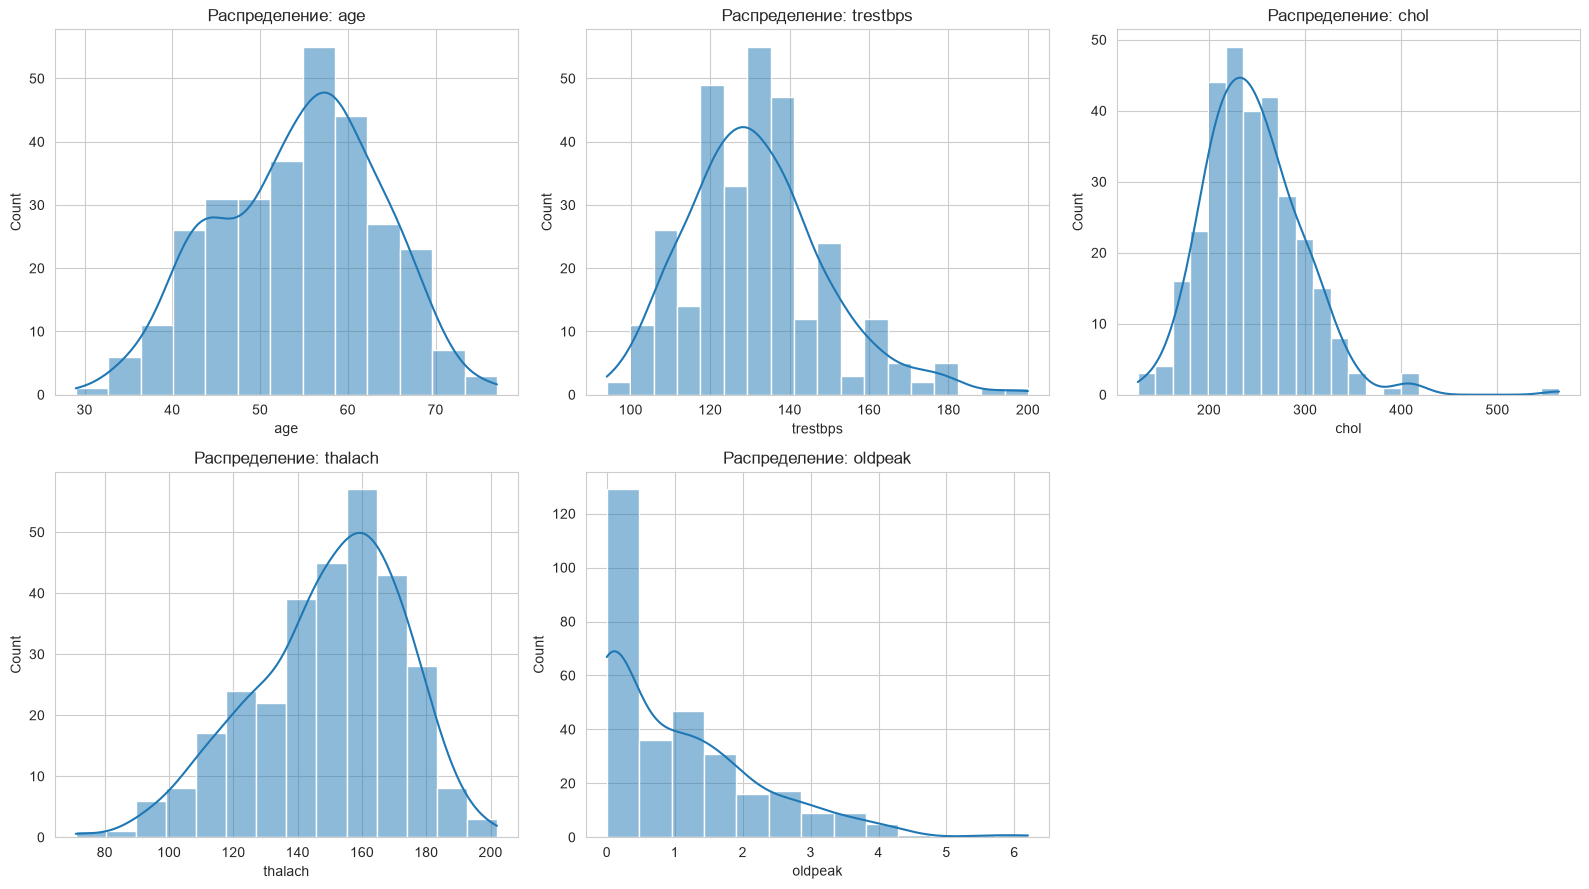

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    sns.histplot(
        data=df,
        x=col,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f'Распределение: {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(
    figures_dir / '1_distributions.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

Boxplots для выявления выбросов 

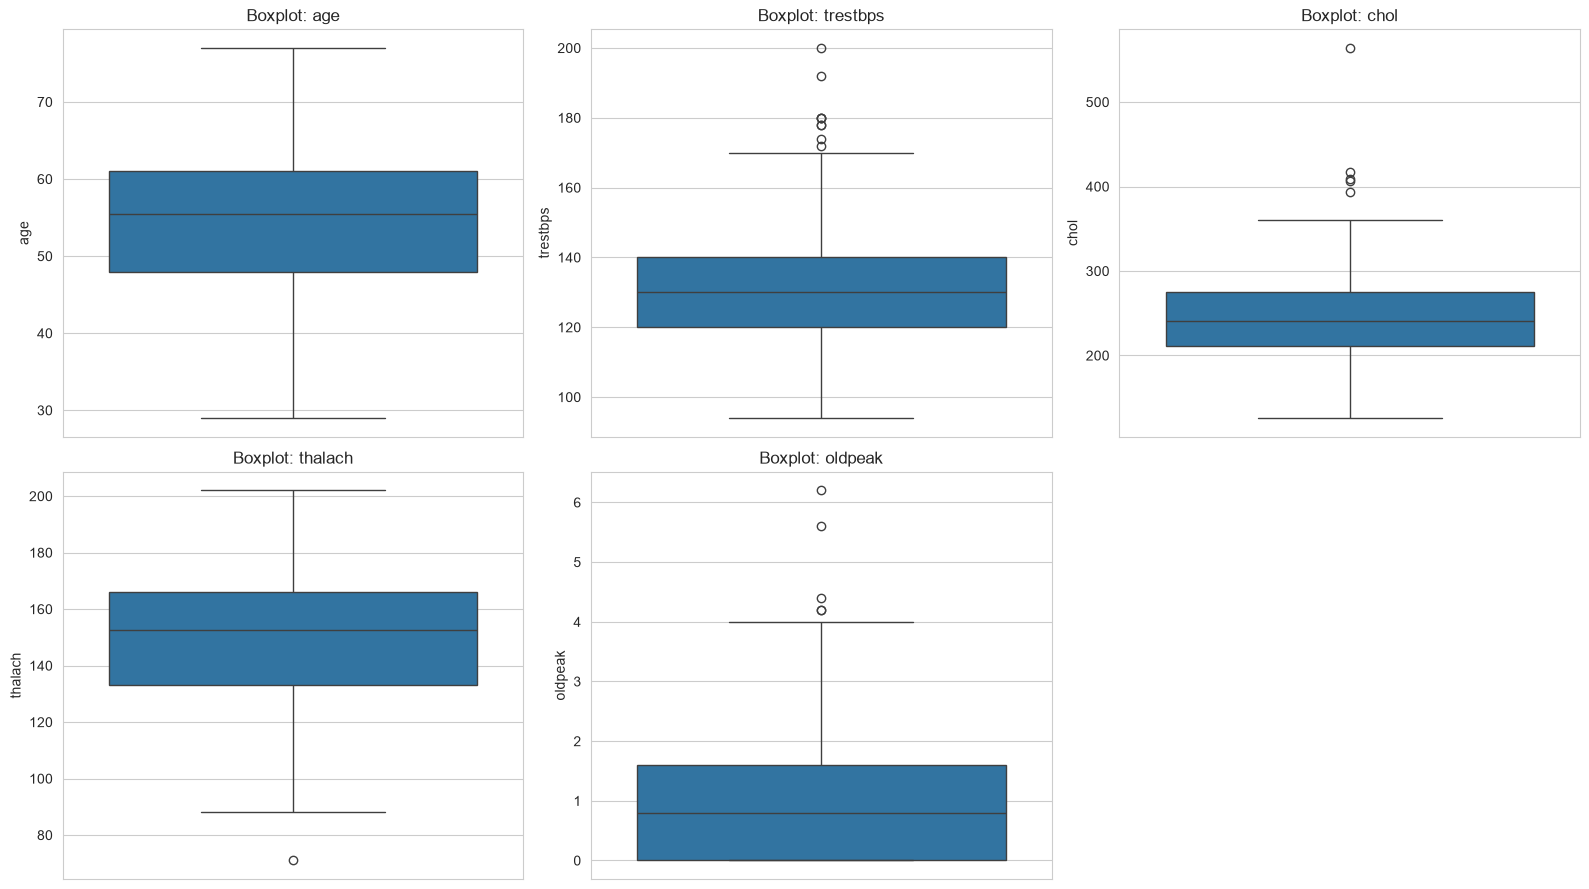

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    sns.boxplot(
        data=df,
        y=col,
        ax=axes[i]
    )
    axes[i].set_title(f'Boxplot: {col}')
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig(
    figures_dir / '2_boxplots.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

# Анализ выбросов

In [14]:
if len(continuous_cols) > 0:
    outliers_report = []
    for col in continuous_cols:
        col_data = df[col].dropna()
        q1 = col_data.quantile(0.25)
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)]
        outliers_report.append({
            'Признак': col,
            'Кол-во выбросов': len(outliers),
            '% выбросов': (len(outliers) / len(col_data)) * 100
        })
    
    outliers_df = pd.DataFrame(outliers_report)
    print(outliers_df)

    Признак  Кол-во выбросов  % выбросов
0       age                0    0.000000
1  trestbps                9    2.980132
2      chol                5    1.655629
3   thalach                1    0.331126
4   oldpeak                5    1.655629


# Корреляционный анализ

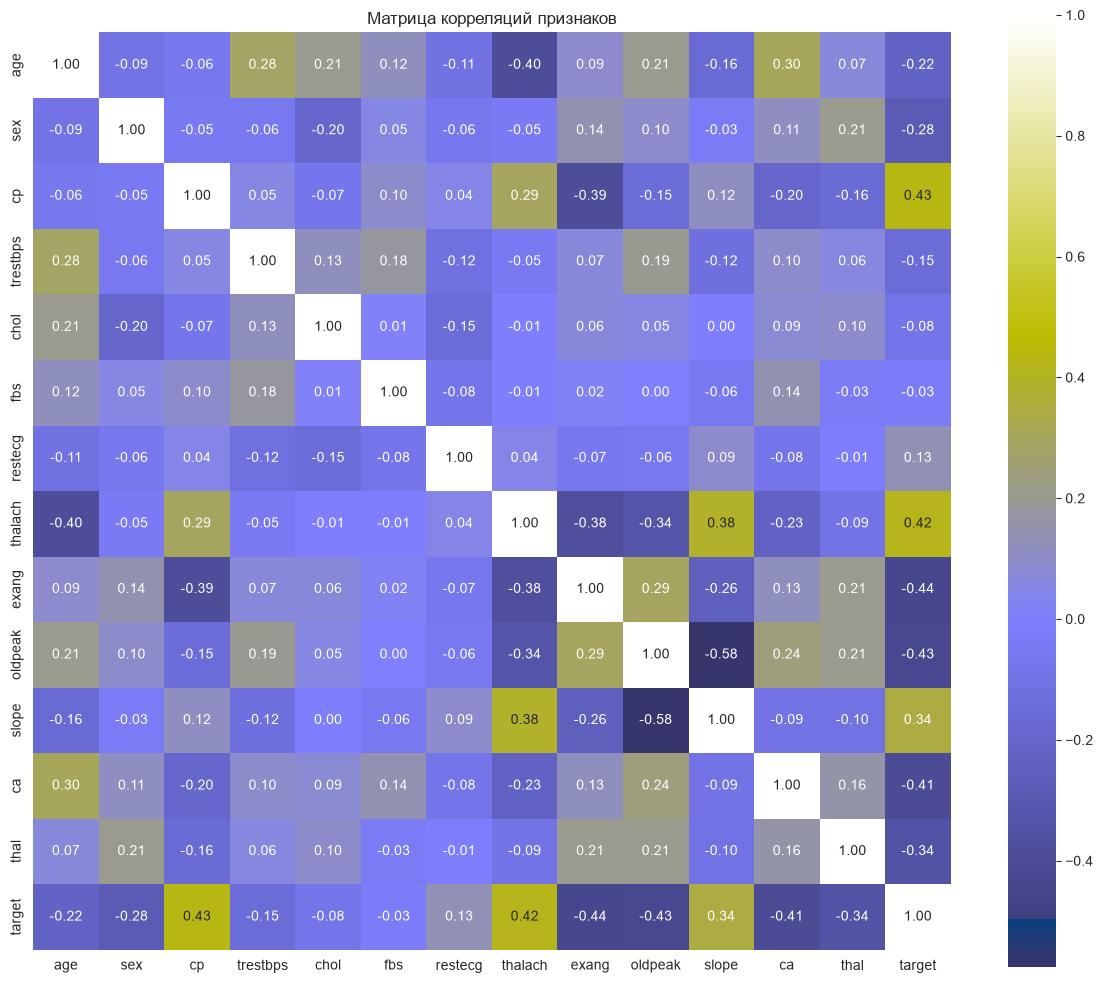


Сильных корреляций не обнаружено


In [15]:
numeric_cols = df.select_dtypes(include=np.number).columns
if len(numeric_cols) > 1:
    # Матрица корреляций
    corr_matrix = df[numeric_cols].corr()
    
    # Тепловая карта корреляций
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, annot=True, cmap='gist_stern', center=0, 
                fmt='.2f', square=True)
    plt.title('Матрица корреляций признаков')
    plt.tight_layout()
    plt.savefig(figures_dir / '3_correlation_matrix.png', dpi=150)
    plt.show()
    
    # Сильные корреляции (>0.7 или < -0.7)
    strong_corrs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                strong_corrs.append({
                    'Признак 1': corr_matrix.columns[i],
                    'Признак 2': corr_matrix.columns[j],
                    'Корреляция': corr_matrix.iloc[i, j]
                })
    
    if strong_corrs:
        print("\nСильные корреляции (|r| > 0.7):")
        print(pd.DataFrame(strong_corrs))
        print("\nРекомендация: можно оставить один из сильно коррелирующих признаков")
    else:
        print("\nСильных корреляций не обнаружено")

# Анализ целевой переменной


Распределение целевой переменной 'target':
   Значение  Количество          %
0         1         164  54.304636
1         0         138  45.695364

Минимальный класс составляет 45.70% от выборки
 Дисбаланс не критичный


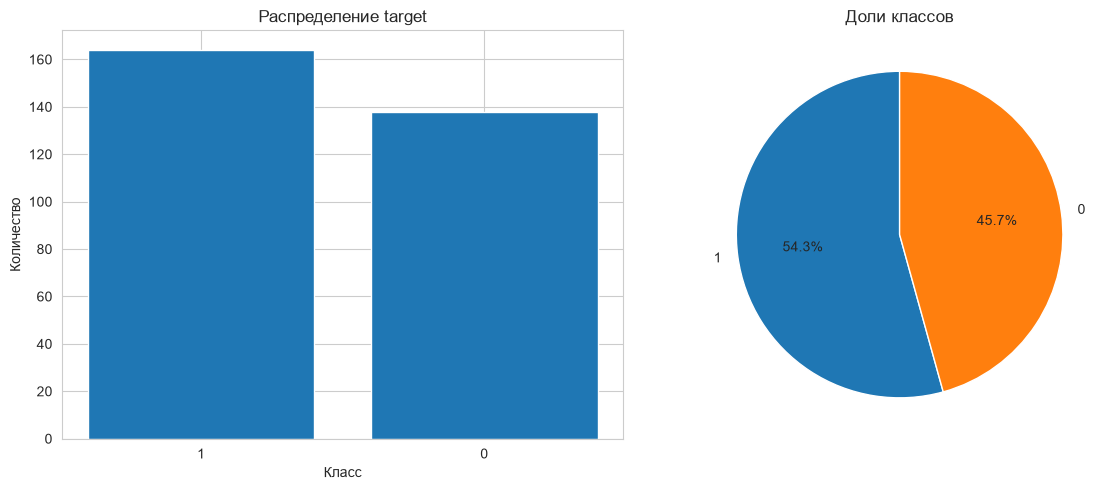

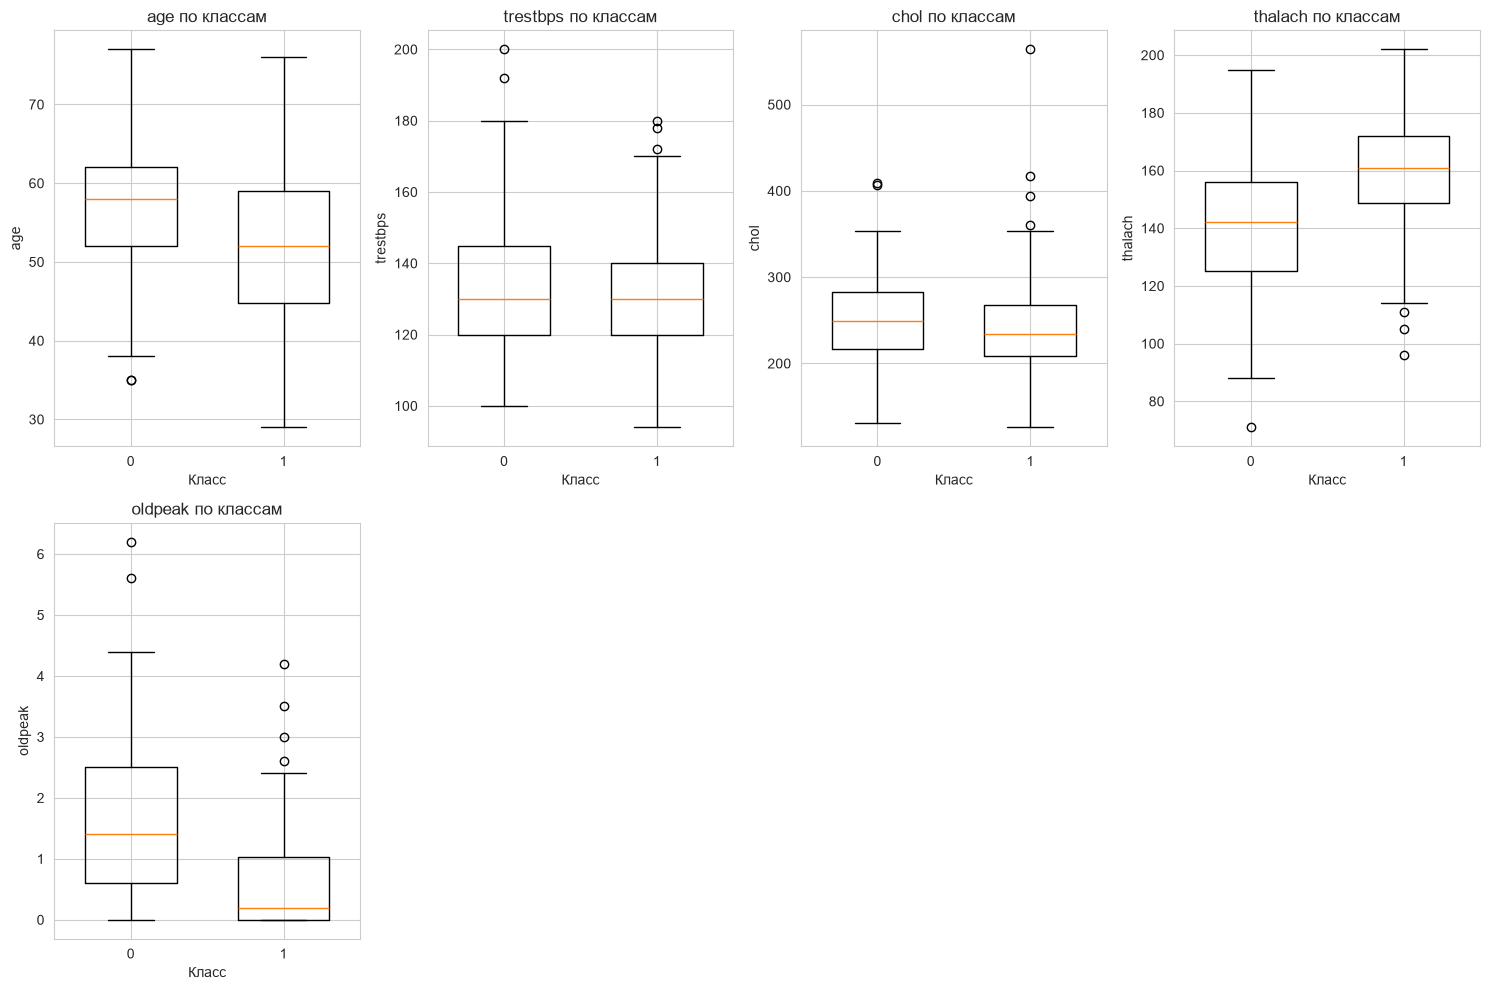

In [16]:
target_col = 'target'
if target_col in df.columns:
    # Распределение целевой переменной
    print(f"\nРаспределение целевой переменной '{target_col}':")
    target_dist = df[target_col].value_counts()
    target_pct = df[target_col].value_counts(normalize=True) * 100
    target_table = pd.DataFrame({
        'Значение': target_dist.index,
        'Количество': target_dist.values,
        '%': target_pct.values
    })
    print(target_table)
    
    # Анализ дисбаланса классов
    min_class_pct = target_pct.min()
    print(f"\nМинимальный класс составляет {min_class_pct:.2f}% от выборки")
    
    if min_class_pct < 10:
        print("Обнаружен сильный дисбаланс классов!")
        print("Рекомендуемые методы борьбы:")
        print(" 1. Использовать class_weight='balanced' в моделях")
        print(" 2. Применить SMOTE для увеличения миноритарного класса")
        print(" 3. Использовать метрики: F1-score, ROC-AUC (не accuracy)")
    else:
        print(" Дисбаланс не критичный")
    
    # Визуализация целевой переменной
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Столбчатая диаграмма
    axes[0].bar(target_dist.index.astype(str), target_dist.values)
    axes[0].set_title(f'Распределение {target_col}')
    axes[0].set_xlabel('Класс')
    axes[0].set_ylabel('Количество')
    
    # Круговая диаграмма
    axes[1].pie(target_dist.values, labels=target_dist.index.astype(str), 
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title(f'Доли классов')
    
    plt.tight_layout()
    plt.savefig(figures_dir / '4_target_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Анализ признаков относительно целевой переменной
    if len(continuous_cols) > 0:
        # Boxplots по классам для каждого числового признака
        n_cols = min(4, len(continuous_cols))
        n_rows = (len(continuous_cols) + n_cols - 1) // n_cols
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
        axes = axes.flatten() if n_rows > 1 else [axes] if n_cols > 1 else [axes]
        
        for i, col in enumerate(continuous_cols[:n_cols*n_rows]):
            for class_val in df[target_col].unique():
                class_data = df[df[target_col] == class_val][col].dropna()
                axes[i].boxplot(class_data, positions=[class_val], widths=0.6)
            axes[i].set_title(f'{col} по классам')
            axes[i].set_xlabel('Класс')
            axes[i].set_ylabel(col)
        
        for j in range(i+1, len(axes)):
            axes[j].set_visible(False)
        
        plt.tight_layout()
        plt.savefig(figures_dir / '5_features_by_class.png', dpi=150, bbox_inches='tight')
        plt.show()

# Предобработка данных

In [17]:
from sklearn.model_selection import train_test_split

# Создаем копию данных для предобработки
df_processed = df.copy()

In [18]:
# Заполняем пропуски 
for col in df_processed.columns:
    if df_processed[col].isnull().sum() > 0:
        if df_processed[col].dtype in ['int64', 'float64']:
            # Числовые признаки: заполняем медианой
            median_val = df_processed[col].median()
            df_processed[col].fillna(median_val, inplace=True)
            print(f"{col}: заполнено {df[col].isnull().sum()} пропусков медианой ({median_val:.2f})")
        else:
            # Категориальные признаки: заполняем модой
            mode_val = df_processed[col].mode()[0]
            df_processed[col].fillna(mode_val, inplace=True)
            print(f"{col}: заполнено {df[col].isnull().sum()} пропусков модой ('{mode_val}')")

In [19]:
# Для решающих деревьев потенциальные выбросы не удаляем и не обрезаем.
# Деревья используют пороговые разбиения и менее чувствительны к масштабу значений.
print('Потенциальные выбросы оставлены без изменения.')

Потенциальные выбросы оставлены без изменения.


In [20]:
# Категориальные признаки в исходном датасете уже представлены числовыми кодами.
# Для базовой модели DecisionTreeClassifier оставляем исходное представление.
# При сравнении моделей можно отдельно проверить вариант с One-Hot Encoding.
print('Дополнительное кодирование категориальных признаков не выполнялось.')

Дополнительное кодирование категориальных признаков не выполнялось.


# Формирование X и y

In [21]:
# Убедимся, что целевая переменная существует
if target_col in df_processed.columns:
    y = df_processed[target_col].values
    X = df_processed.drop(columns=[target_col])
    
    print(f"Матрица признаков X: {X.shape[0]} объектов, {X.shape[1]} признаков")
    print(f"Целевая переменная y: {y.shape[0]} значений")
    print(f"Уникальные классы в y: {np.unique(y)}")
else:
    print(f"целевая переменная '{target_col}' не найдена в данных")
    print(f"Доступные колонки: {list(df_processed.columns)}")

Матрица признаков X: 302 объектов, 13 признаков
Целевая переменная y: 302 значений
Уникальные классы в y: [0 1]


# Разделение на train, validation, test 

In [22]:
from sklearn.model_selection import train_test_split

# Сначала отделяем тестовую выборку (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y  # стратификация - сохраняем пропорции классов
)

# Затем разделяем оставшиеся 80% на train (60%) и validation (20% от исходных)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.25,  # 0.25 * 0.8 = 0.2 от исходных
    random_state=42,
    stratify=y_temp
)

print(f"Размер обучающей выборки (train): {X_train.shape[0]} объектов ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Размер валидационной выборки (val): {X_val.shape[0]} объектов ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"Размер тестовой выборки (test): {X_test.shape[0]} объектов ({X_test.shape[0]/len(X)*100:.1f}%)")

# Проверка стратификации
print("\nПроверка стратификации (распределение классов):")
print("Train:", np.bincount(y_train) / len(y_train))
print("Val:  ", np.bincount(y_val) / len(y_val))
print("Test: ", np.bincount(y_test) / len(y_test))

# После удаления полных дубликатов одинаковые строки не должны попадать
# одновременно в разные выборки.
train_rows = set(map(tuple, X_train.to_numpy()))
val_rows = set(map(tuple, X_val.to_numpy()))
test_rows = set(map(tuple, X_test.to_numpy()))
print("\nПересечение train/val:", len(train_rows & val_rows))
print("Пересечение train/test:", len(train_rows & test_rows))
print("Пересечение val/test:", len(val_rows & test_rows))


Размер обучающей выборки (train): 180 объектов (59.6%)
Размер валидационной выборки (val): 61 объектов (20.2%)
Размер тестовой выборки (test): 61 объектов (20.2%)

Проверка стратификации (распределение классов):
Train: [0.45555556 0.54444444]
Val:   [0.45901639 0.54098361]
Test:  [0.45901639 0.54098361]

Пересечение train/val: 0
Пересечение train/test: 0
Пересечение val/test: 0


# Сохраним данные 

In [23]:
processed_dir = Path('../data/processed')
processed_dir.mkdir(parents=True, exist_ok=True)

df_processed.to_csv(
    processed_dir / 'heart_deduplicated.csv',
    index=False
)

np.save(processed_dir / 'X_train.npy', X_train)
np.save(processed_dir / 'X_val.npy', X_val)
np.save(processed_dir / 'X_test.npy', X_test)

np.save(processed_dir / 'y_train.npy', y_train)
np.save(processed_dir / 'y_val.npy', y_val)
np.save(processed_dir / 'y_test.npy', y_test)

with open(
    processed_dir / 'feature_names.txt',
    'w',
    encoding='utf-8'
) as file:
    for col in X.columns:
        file.write(col + '\n')

print('Файлы сохранены в:', processed_dir.resolve())

Файлы сохранены в: C:\Practice_DecisionTreeClassifier\data\processed
